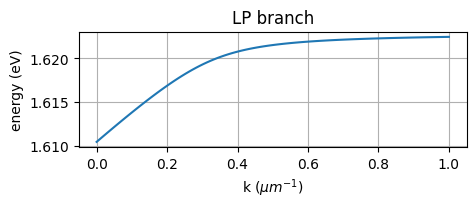

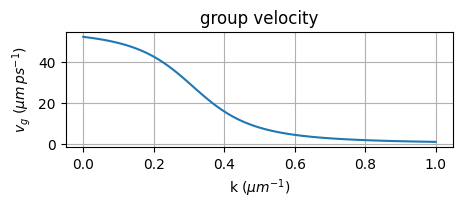

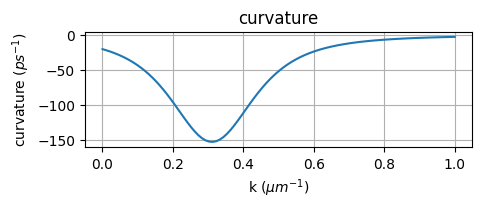

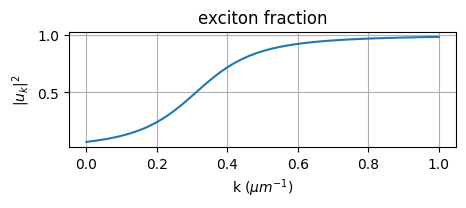

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

Mc = lambda k: 1.6114 + 0.037 * k  # (photonic mode approximated as a straight line)
Exca = 1.6229  # (exciton energy)
OM = 3.4 * 1e-3 # (half the Rabi splitting)
hbar_eV_ps = 6.582 * 1e-4 # hbar, converting energy to frequency (eV to 1/ps)
hbar_ueV_ps = 6.582 * 1e2 # hbar, converting energy to frequency (ueV to 1/ps)

def omega_LP(k: float):
    """
    Lower-polariton dispersion in eV and um!

    """

    LP_disp =  0.5 * (Mc(k) + Exca) - 0.5 * ((Mc(k) - Exca)**2 + 4. * OM ** 2) ** 0.5
    return LP_disp


def vg_LP(k: float, dk: float=1e-3) -> np.array:
    "LP group velocity in units um/ps"
    return (omega_LP(k + dk/2.) - omega_LP(k - dk/2.)) / dk / hbar_eV_ps

def curvature_LP(k: float, dk: float=1e-3) -> np.array:
    "branch curvature, in ps^-1, mass is inverse "
    curvature = (vg_LP(k + dk/2, dk) - vg_LP(k - dk/2, dk)) / dk # derivative of group velocity
    return curvature


def exciton_fraction(k):
    theta_k = np.arctan(OM / (omega_LP(k) - Mc(k)))
    return np.cos(theta_k) ** 2


k = np.linspace(0., 1, 100)

plt.figure(figsize=(5,1.5))
plt.plot(k, omega_LP(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"energy (eV)")
plt.title("LP branch")
plt.grid('minor')

plt.figure(figsize=(5,1.5))
plt.plot(k, vg_LP(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$v_g$ ($\mu m\, ps^{-1}$)")
plt.title("group velocity")
plt.grid('minor')

plt.figure(figsize=(5,1.5))
plt.plot(k, curvature_LP(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"curvature ($ps^{-1}$)")
plt.title("curvature")
plt.grid('minor')

plt.figure(figsize=(5,1.5))
plt.plot(k, exciton_fraction(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$|u_k|^2$")
plt.title("exciton fraction")
plt.grid('minor')

In [ ]:
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple, List, Any



class SchrodingerEquation:

    def __init__(
        self,
        z: torch.Tensor,
        g: float,
        dispersion: torch.Tensor,
        dt: float = 0.01,
        V: np.ndarray|None = None
    ):
        
        self.z = z
        self.g = g
        self.dispersion = dispersion
        self.dt = dt
        self.V = V

        # get some useful parameters
        self.device = self.z.device

        self.dz = self.z[1] - self.z[0]
        self.nz = self.z.numel()

        # the FFT phase, to be applied in two directions k0, k1
        self.kinetic_phase = torch.exp(-1j * (self.dispersion * dt)).unsqueeze(0)



    def run(
        self,
        psi: torch.Tensor, 
        t_samples: torch.Tensor,
        start_time: float=0.,
        store_device: str='same'
    ) -> Tuple[torch.Tensor,torch.Tensor]:
        
        """
        Forward step: Evolve the 2D Gross-Pitaevskii Equation using the split-step Fourier method.
    
        """

        # Time evolution
        t = start_time
        t_max = t_samples[-1]
        num_collect = t_samples.numel()

        t_values = torch.arange(0, t_max + self.dt, self.dt)  # Ensure we step through exact times
        collect_inds = torch.searchsorted(t_values, t_samples) 
        num_steps = t_values.numel()
        num_collect = collect_inds.numel()
        
        # the collection of psis to be returned at the end
        store_device = psi.device if store_device=='same' else store_device
        psi_collect = torch.empty((num_collect, *psi.shape), dtype=psi.dtype, device=store_device)

        sample_idx = 0
        if 0 in collect_inds:
            psi_collect[sample_idx] = psi.clone()
            sample_idx += 1


        ###################################################################
        #               START THE LOOP                                    #
        ###################################################################

        for i_step in tqdm(range(num_steps), desc="Forward pass GPE..."):

            # potential evolution
            if self.V is not None:
                psi = psi * torch.exp(-1j * self.V * dt / 2)

            # interaction -> diagonal
            ind = range(self.nz)
            psi[ind,ind] = psi.diag() * np.exp( -1j * self.g * self.dt / 2)
            # psi = psi * torch.exp(-1j * (self.V + self.g * torch.abs(psi) ** 2) * self.dt / 2)


            
            # Kinetic evolution (diagonal in momentum space, apply in two directions -> .T)
            psi_k = torch.fft.fft2(psi)
            psi_k = psi_k * self.kinetic_phase
            psi_k = psi_k * self.kinetic_phase.T
            psi = torch.fft.ifft2(psi_k)
            
                # potential evolution
            if self.V is not None:
                psi = psi * torch.exp(-1j * self.V * dt / 2.)

            # interaction -> diagonal
            ind = range(self.nz)
            psi[ind,ind] = psi.diag() * np.exp( -1j * self.g * self.dt / 2)
            # psi = psi * torch.exp(-1j * (self.V + self.g * torch.abs(psi) ** 2) * self.dt / 2)

            t += self.dt

            # check if result needs to be stored for sampling times
            if i_step + 1 in collect_inds:
                psi_collect[sample_idx] = psi.clone().to(store_device)
                sample_idx += 1
            
        t_sampled = t_values[collect_inds].to(store_device)
        return t_sampled, psi_collect



device = 'cuda:4'

zmax = 1000. # grid -zmax <-> + zmax, in um
nz = 801 # number of subdivisions

duration = 1 # ps
hg_ex = 1400 # ueV * um
x_prop = 500 # um
ref_k = .3 # um^{-1}
group_velocity = vg_LP(ref_k) # in um / ps

dt = 0.1
t_max = x_prop / group_velocity
t_samples = torch.linspace(0, t_max, 3) # in ps


# the grid
z = torch.linspace(-zmax, zmax, nz, device=device, dtype=torch.complex128)
Z1, Z2 = torch.meshgrid(z,z, indexing='ij')
dz = z[1] - z[0]

# spatial extent
sigma_z = duration * group_velocity

# photon profile
profile = torch.exp(- 0.25 * z ** 2 / sigma_z ** 2)
profile = profile / torch.sqrt((torch.abs(profile) ** 2).sum() * dz)

# two-photon profile
psi = torch.outer(profile, profile)

# dispersion
kz = torch.fft.fftfreq(nz, d=dz, device=device) * 2 * torch.pi
wk = (omega_LP(kz + ref_k) - omega_LP(ref_k)) / hbar_eV_ps \
      - group_velocity * kz # don't forget to bring omega from eV to ps -> / hbar (in right units!)
g = (hg_ex/ hbar_ueV_ps) * exciton_fraction(ref_k) ** 2 / dz.cpu().numpy()
#g = (hg_ex/ hbar_ueV_ps) *  dz.cpu().numpy()

# plot
se = SchrodingerEquation(z=z, g=g, dispersion=wk, dt=dt)

samples_, psi_collect = se.run(psi, t_samples)





Forward pass GPE...:  14%|█▎        | 23/170 [00:00<00:00, 225.90it/s]

Forward pass GPE...: 100%|██████████| 170/170 [00:00<00:00, 272.45it/s]


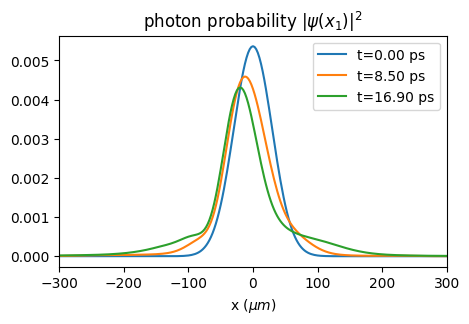

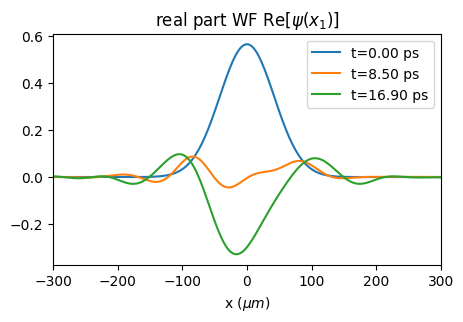

exciton fraction: 0.47
group_velocity: 29.76 um/ps
$\hbar g$: 0.9422712889264822 1/ps


In [15]:
zmax = 300

plt.figure(figsize=(5,3))
plt.plot(z.cpu(), psi_collect.abs().pow(2).sum(dim=-1).cpu().T)
plt.xlim([-zmax, zmax])
plt.legend([f"t={t:.2f} ps" for t in samples_], loc="upper right")
plt.title(r"photon probability $|\psi(x_1)|^2$")
plt.xlabel(r"x $(\mu m)$")
plt.show()

plt.figure(figsize=(5,3))
plt.plot(z.cpu(), psi_collect.sum(dim=-1).real.cpu().T)
plt.xlim([-zmax, zmax])
plt.legend([f"t={t:.2f} ps" for t in samples_], loc="upper right")
plt.title(r"real part WF $\text{Re}[\psi(x_1)]$")
plt.xlabel(r"x $(\mu m)$")
plt.show()

print(f"exciton fraction: {exciton_fraction(ref_k):.2f}")
print(f"group_velocity: {vg_LP(ref_k):.2f} um/ps")
print(rf"$\hbar g$: {exciton_fraction(ref_k) ** 2 * (hg_ex / hbar_ueV_ps) / 0.5} 1/ps")

/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/numpy/ma/core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/transforms.py:2876: ComplexWarning: Casting complex values to real discards the imaginary part
  vmin, vmax = map(float, [vmin, vmax])
/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/collections.py:2447: ComplexWarning: Casting complex values to real discards the imaginary part
  renderer.draw_quad_mesh(


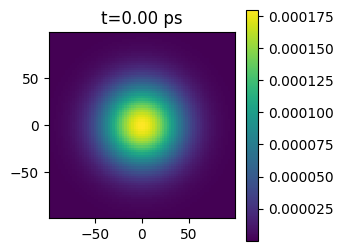

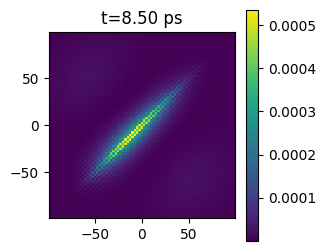

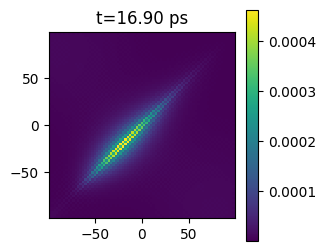

In [16]:
z_max_show = 100
inds = np.sum(z.cpu().numpy() < z_max_show)
z_plot = z.cpu()[-inds:inds]
for t, psi in zip(samples_, psi_collect):
    plt.figure(figsize=(3,3))
    plt.pcolormesh(z_plot, z_plot, psi.cpu()[-inds:inds,-inds:inds].abs().pow(2))
    plt.title(f"t={t:.2f} ps")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.colorbar()
    plt.show()


In [ ]:
psi_collect[-1].abs().pow(2).sum() * dz ** 2

tensor(1.0000+0.j, device='cuda:0', dtype=torch.complex128)

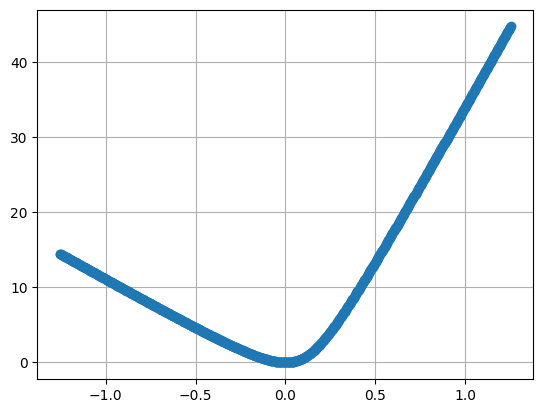

In [ ]:
plt.plot(kz.cpu(), wk.cpu(), "o")
plt.grid(True)

In [ ]:
num_photon = 3

d = torch.rand(100)

ten = d.clone()
for _ in range(num_photon-1):
    ten = ten.unsqueeze(-1) * d

ten.shape

torch.Size([401, 401, 401])

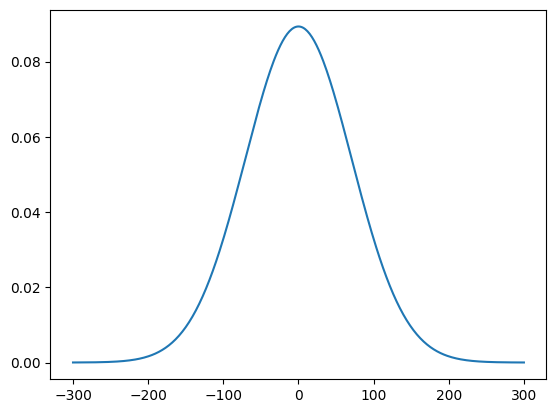

In [ ]:
plt.plot(z, profile)

In [25]:
import torch.nn.functional as F

n = torch.tensor(0.0)
F.relu( 0.05 - n) / 0.05

tensor(1.)